# 08 — Gradient Boosting Regressor (Regression Track)
**23CSE301 Machine Learning — Capstone, Review 1**

**Dataset:** UK Used Cars (`used_cars.csv`) **Target:** `price` (£)

| Block | Rubric section |
|---|---|
| 1 | Section A — Dataset & EDA |
| 2 | Section B — Preprocessing & Feature Engineering |
| 3 | Section C — Regression Track (Gradient Boosting Regressor) |

Gradient Boosting builds trees **one after another**. Each new small tree is trained to predict the **errors (residuals)** of all the trees before it, and its prediction is added after multiplying by the **learning rate**. A small learning rate learns slowly but generalises better (and needs more trees). Key hyperparameters: **learning_rate**, number of trees, and tree size.

---
# BLOCK 1 — Dataset & EDA (Section A)

In [1]:
# ============================================================
# BLOCK 1 : DATASET & EDA
# ============================================================

# ---- 1.0 Imports & global settings ----
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                      # fixed seed for reproducibility (guideline 7.1)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")   # colour-blind-friendly palette (guideline 7.3)
pd.set_option("display.max_columns", 50)

DATA_PATH = "../data/used_cars.csv"    # change if your file is somewhere else
TARGET = "price"

## A1 — Dataset loading & audit
Shape, dtypes, missing values, duplicates and target distribution.

In [2]:
# ---- 1.1 Load the dataset ----
df = pd.read_csv(DATA_PATH)

# 'Unnamed: 0' is just an old row index saved into the CSV -> not a real feature
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Some text columns have stray spaces (e.g. ' T-Roc') -> strip them
for col in df.select_dtypes(include="object").columns.union(df.select_dtypes(include="string").columns):
    df[col] = df[col].astype(str).str.strip()

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (99187, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW


In [3]:
# ---- 1.2 Data types & basic info ----
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
print("Duplicate rows:", df.duplicated().sum())
audit

Duplicate rows: 1475


,dtype,missing_count,missing_%,n_unique
model,str,0,0.0,195
year,int64,0,0.0,27
price,int64,0,0.0,13236
transmission,str,0,0.0,4
mileage,int64,0,0.0,42214
fuelType,str,0,0.0,5
tax,int64,0,0.0,48
mpg,float64,0,0.0,208
engineSize,float64,0,0.0,40
Make,str,0,0.0,9


In [4]:
# ---- 1.3 Statistical summary of numeric columns ----
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,99187.0,2017.087723,2.123934,1970.0,2016.0,2017.0,2019.0,2060.0
price,99187.0,16805.347656,9866.773417,450.0,9999.0,14495.0,20870.0,159999.0
mileage,99187.0,23058.914213,21148.523721,1.0,7425.0,17460.0,32339.0,323000.0
tax,99187.0,120.299838,63.150926,0.0,125.0,145.0,145.0,580.0
mpg,99187.0,55.166825,16.138522,0.3,47.1,54.3,62.8,470.8
engineSize,99187.0,1.663280,0.557646,0.0,1.2,1.6,2.0,6.6


In [5]:
# ---- 1.4 Target distribution summary ----
print(df[TARGET].describe())
print("\nSkewness of price:", round(df[TARGET].skew(), 3))

# Category counts (the 'class distribution' view for the categorical columns)
for col in ["Make", "transmission", "fuelType"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

count     99187.000000
mean      16805.347656
std        9866.773417
min         450.000000
25%        9999.000000
50%       14495.000000
75%       20870.000000
max      159999.000000
Name: price, dtype: float64

Skewness of price: 2.347

--- Make ---
Make
ford        17965
VW          15157
vauxhall    13632
merc        13119
BMW         10781
Audi        10668
toyota       6738
skoda        6267
hyundi       4860
Name: count, dtype: int64

--- transmission ---
transmission
Manual       56445
Semi-Auto    22677
Automatic    20056
Other            9
Name: count, dtype: int64

--- fuelType ---
fuelType
Petrol      54928
Diesel      40928
Hybrid       3078
Other         247
Electric        6
Name: count, dtype: int64


## A2 — EDA visualisations

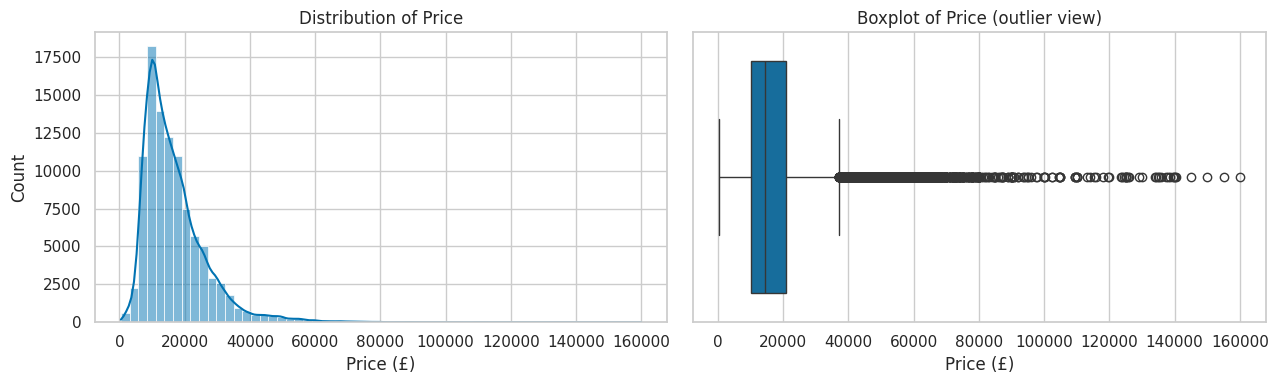

In [6]:
# ---- 1.5 Target distribution (price) ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Price")
axes[0].set_xlabel("Price (£)"); axes[0].set_ylabel("Count")

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Boxplot of Price (outlier view)")
axes[1].set_xlabel("Price (£)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Most cars cost between £10,000 and £21,000, but a few cost up to £160,000, so the price chart has a long tail on the right.

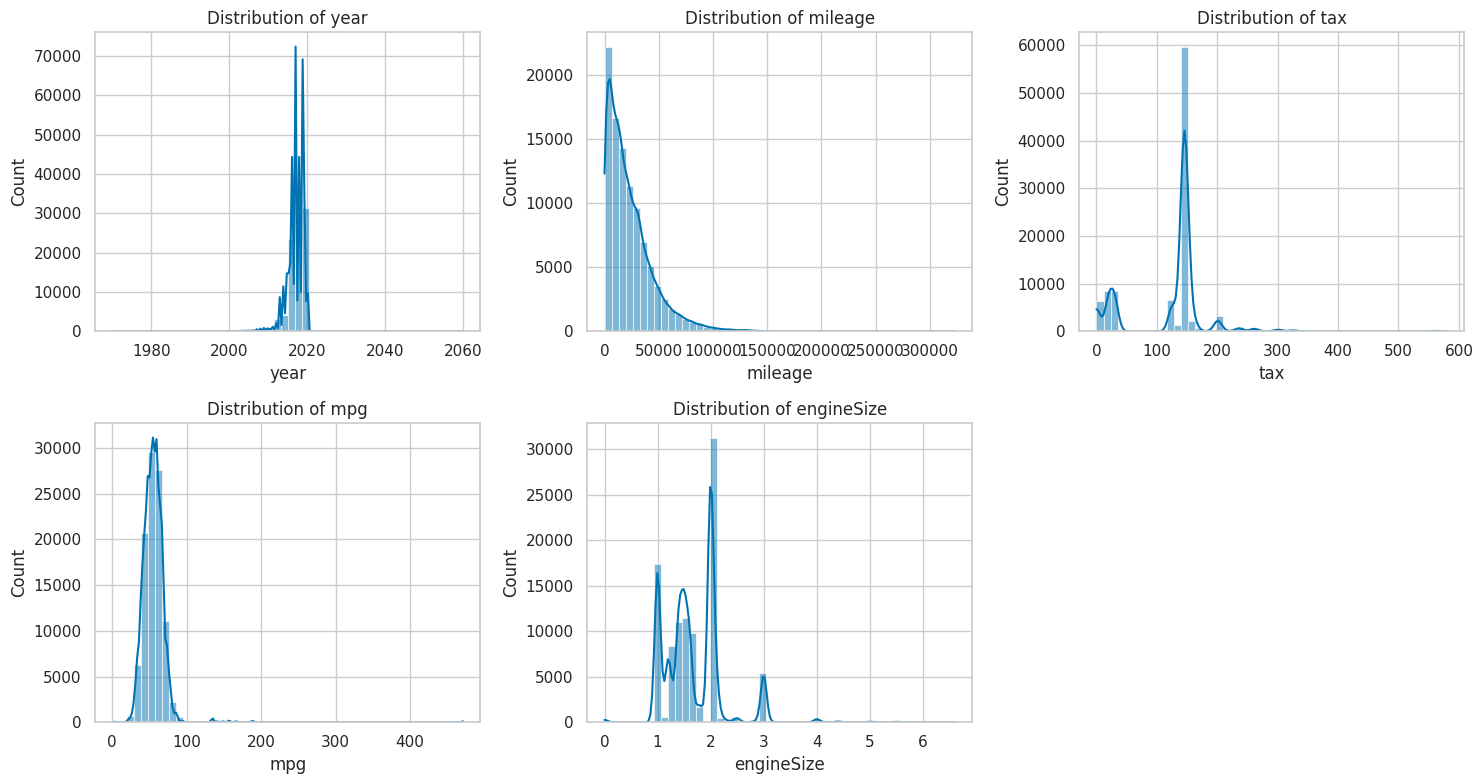

In [7]:
# ---- 1.6 Distribution plot for EACH numeric feature ----
num_features = ["year", "mileage", "tax", "mpg", "engineSize"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_features):
    sns.histplot(df[col], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
axes.flat[-1].set_visible(False)       # hide the unused 6th subplot
plt.tight_layout(); plt.show()

**📝 What this shows:** Most cars are recent and low-mileage, and there are a few impossible values: one car dated 2060, some with 470 mpg, and 266 with a 0-litre engine.

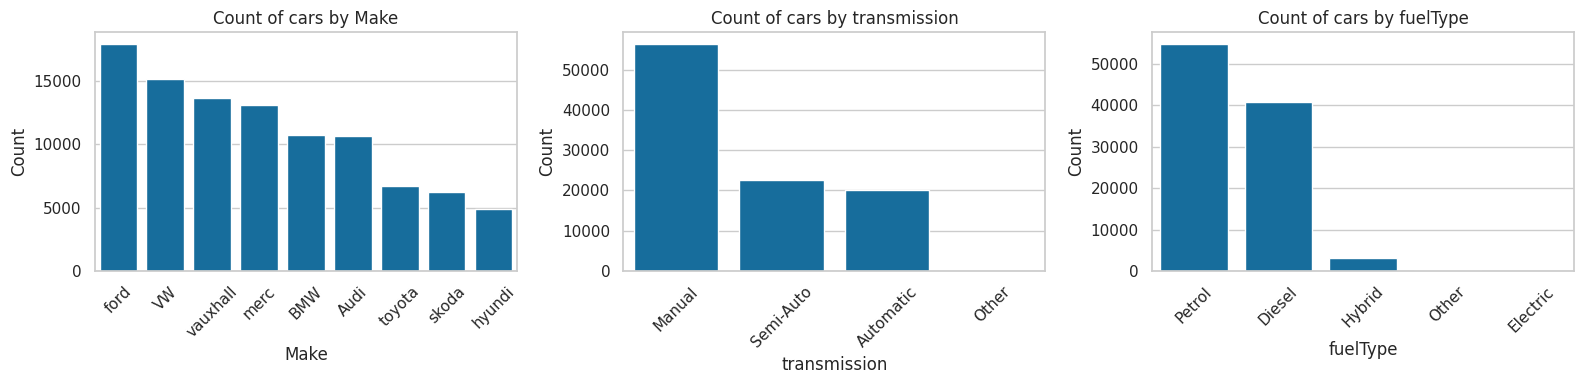

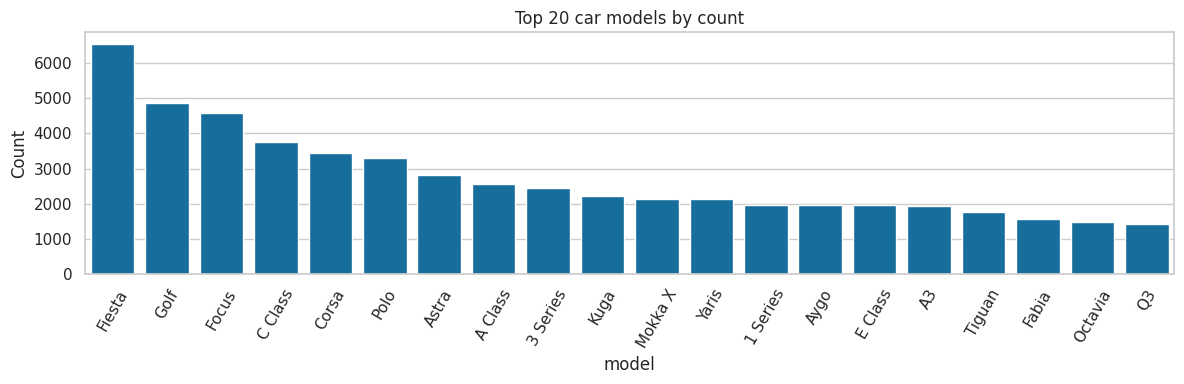

In [8]:
# ---- 1.7 Distribution plot for EACH categorical feature ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Make", "transmission", "fuelType"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(f"Count of cars by {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# 'model' has ~195 values -> show only the top 20
plt.figure(figsize=(12, 4))
top_models = df["model"].value_counts().head(20)
sns.barplot(x=top_models.index, y=top_models.values)
plt.title("Top 20 car models by count")
plt.xlabel("model"); plt.ylabel("Count"); plt.xticks(rotation=60)
plt.tight_layout(); plt.show()

**📝 What this shows:** Ford and VW are the most common brands, most cars are manual, and petrol and diesel cover nearly everything — electric cars are almost absent (only 6).

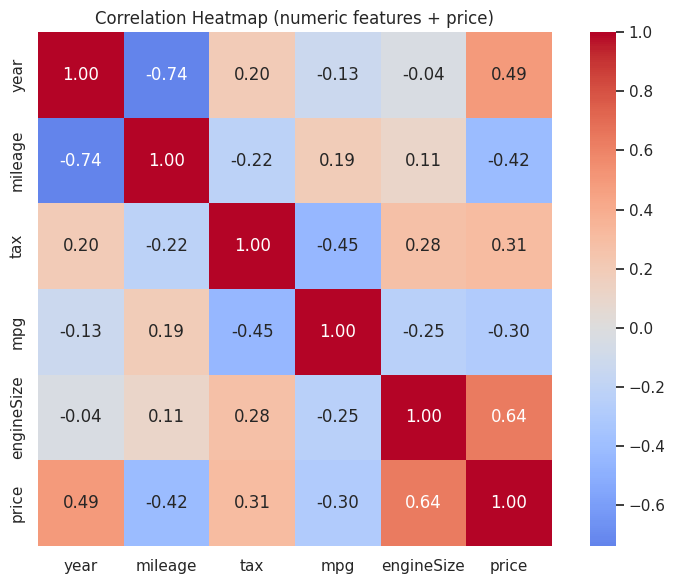

In [9]:
# ---- 1.8 Correlation heatmap (numeric columns incl. target) ----
plt.figure(figsize=(8, 6))
corr = df[num_features + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features + price)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Price goes up with engine size (0.65) and newer year (0.49), and goes down as mileage rises (−0.42).

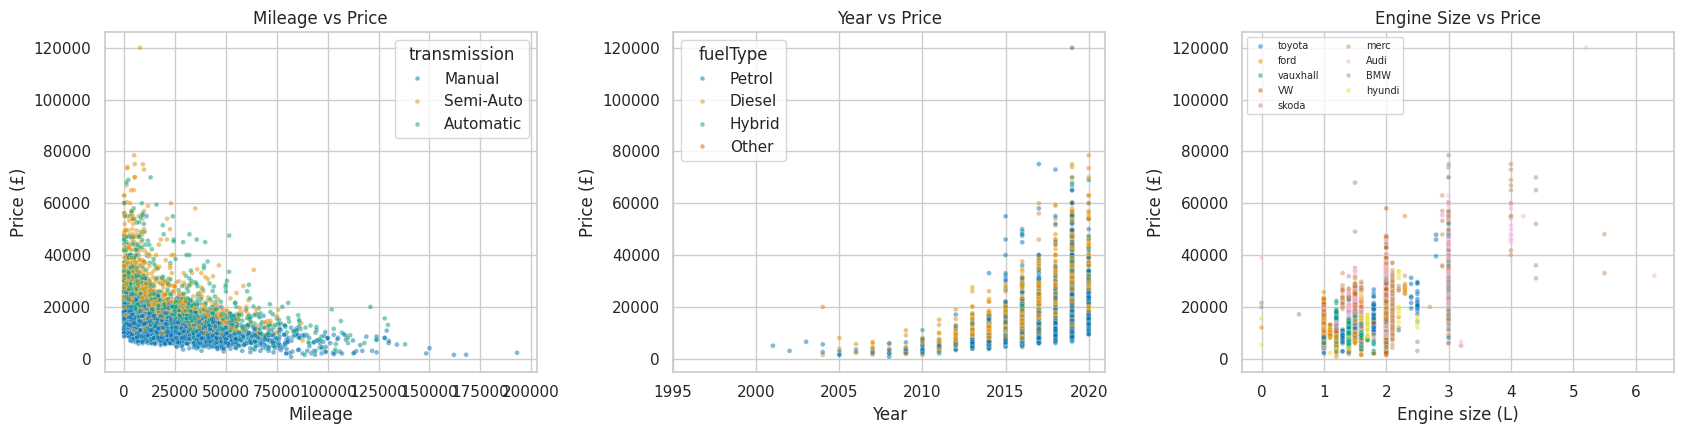

In [10]:
# ---- 1.9 Scatter plots: feature vs target ----
sample = df.sample(5000, random_state=RANDOM_STATE)   # sample so the plot is readable

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=sample, x="mileage", y=TARGET, hue="transmission", alpha=0.5, s=12, ax=axes[0])
axes[0].set_title("Mileage vs Price"); axes[0].set_xlabel("Mileage"); axes[0].set_ylabel("Price (£)")

sns.scatterplot(data=sample, x="year", y=TARGET, hue="fuelType", alpha=0.5, s=12, ax=axes[1])
axes[1].set_title("Year vs Price"); axes[1].set_xlabel("Year"); axes[1].set_ylabel("Price (£)")
axes[1].set_xlim(1995, 2021)

sns.scatterplot(data=sample, x="engineSize", y=TARGET, hue="Make", alpha=0.5, s=12, ax=axes[2])
axes[2].set_title("Engine Size vs Price"); axes[2].set_xlabel("Engine size (L)"); axes[2].set_ylabel("Price (£)")
axes[2].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

**📝 What this shows:** The lines are curved, not straight: price drops fast in the first few years and miles, then flattens out.

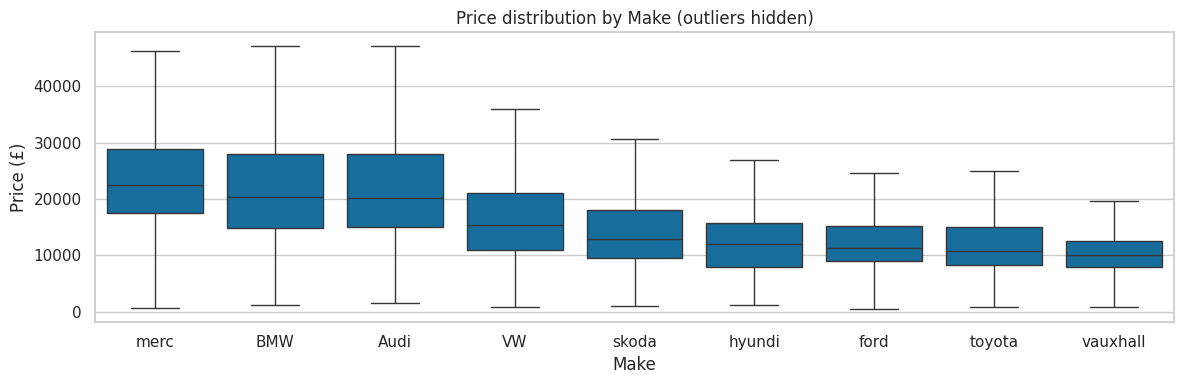

In [11]:
# ---- 1.10 Price by brand (categorical feature vs target) ----
plt.figure(figsize=(12, 4))
order = df.groupby("Make")[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Make", y=TARGET, order=order, showfliers=False)
plt.title("Price distribution by Make (outliers hidden)")
plt.xlabel("Make"); plt.ylabel("Price (£)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Mercedes, BMW and Audi cost about twice as much as Vauxhall and Toyota, so the brand matters a lot.

---
# BLOCK 2 — Preprocessing & Feature Engineering (Section B)

In [12]:
# ============================================================
# BLOCK 2 : PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ---- 2.1 Remove duplicate rows ----
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}  ->  rows now: {len(df)}")

# ---- 2.2 Remove impossible / invalid rows ----
# year > 2020 is impossible for this dataset (data was collected in 2020)
invalid_year = df["year"] > 2020
print("Rows with invalid year (>2020):", invalid_year.sum())
df = df[~invalid_year].reset_index(drop=True)

# ---- 2.3 Hidden missing values ----
# The CSV has no NaNs, but engineSize = 0 is not a real engine size for petrol/diesel cars,
# so we treat it as 'missing' and impute it later (after the split, using train data only).
hidden_missing = (df["engineSize"] == 0) & (df["fuelType"] != "Electric")
print("engineSize == 0 (treated as missing):", hidden_missing.sum())
df.loc[hidden_missing, "engineSize"] = np.nan
print("\nMissing values now:\n", df.isnull().sum()[df.isnull().sum() > 0])

Duplicates removed: 1475  ->  rows now: 97712
Rows with invalid year (>2020): 1
engineSize == 0 (treated as missing): 266

Missing values now:
 engineSize    266
dtype: int64


**Missing-value strategy:** `engineSize` NaNs are filled with the **median engine size of the same car model**
(computed on the training set only), falling back to the overall training median. The same model almost always
has a similar engine, and the median is robust to outliers.

## B3 — Feature engineering

In [13]:
# ---- 2.4 Engineered features ----
REF_YEAR = 2020                                            # year the data was collected
df["car_age"] = REF_YEAR - df["year"]                      # age of the car in years
df["mileage_per_year"] = df["mileage"] / (df["car_age"] + 1)   # +1 avoids divide-by-zero for 2020 cars

df[["year", "car_age", "mileage", "mileage_per_year", TARGET]].corr()[TARGET]

year                0.492556
car_age            -0.492556
mileage            -0.417987
mileage_per_year   -0.294263
price               1.000000
Name: price, dtype: float64

**Why these features may help:**
- `car_age` — depreciation depends on how old a car is; age is easier to interpret than the raw year.
- `mileage_per_year` — separates a *heavily used* young car from a *lightly used* old car, which raw
  mileage alone cannot do. Usage intensity affects wear and resale value.

## B2 — Stratified train/test split, encoding & scaling

In [14]:
# ---- 2.5 Separate features and target ----
cat_cols = ["model", "transmission", "fuelType", "Make"]
num_cols = ["mileage", "tax", "mpg", "engineSize", "car_age", "mileage_per_year"]
# ('year' is dropped because car_age carries the same information)

X = df[cat_cols + num_cols]
y = df[TARGET]

# ---- 2.6 Stratified 80:20 split ----
# price is continuous, so we stratify on price *bins* (quintiles)
# -> train and test get the same spread of cheap / mid / expensive cars
price_bins = pd.qcut(y, q=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=price_bins
)
X_train, X_test = X_train.copy(), X_test.copy()
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Mean price  train: %.0f | test: %.0f" % (y_train.mean(), y_test.mean()))

Train: (78168, 10)  Test: (19543, 10)
Mean price  train: 16778 | test: 16756


In [15]:
# ---- 2.7 Impute engineSize (statistics from TRAIN only) ----
model_median = X_train.groupby("model")["engineSize"].median()
global_median = X_train["engineSize"].median()

for part in (X_train, X_test):
    part["engineSize"] = part["engineSize"].fillna(part["model"].map(model_median)).fillna(global_median)

print("Missing after imputation -> train:", X_train.isnull().sum().sum(), "| test:", X_test.isnull().sum().sum())

Missing after imputation -> train: 0 | test: 0


In [16]:
# ---- 2.8 Outlier check (IQR) & treatment (capping) ----
outlier_report = {}
caps = {}
for col in ["mileage", "tax", "mpg", "engineSize", "mileage_per_year"]:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report[col] = int(((X_train[col] < low) | (X_train[col] > high)).sum())
    # Cap at the 1st / 99th percentile of TRAIN (keeps rows, limits extreme values)
    caps[col] = (X_train[col].quantile(0.01), X_train[col].quantile(0.99))

print("IQR outliers in train set:")
print(pd.Series(outlier_report))

for col, (lo, hi) in caps.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)     # same train-derived limits applied to test

IQR outliers in train set:
mileage              3075
tax                 22880
mpg                   712
engineSize            548
mileage_per_year     1773
dtype: int64


**Outlier strategy:** values are **capped** at the train-set 1st/99th percentiles instead of deleted — rows are kept,
but impossible values (e.g. mpg = 470) can no longer distort the model. The target `price` is **not** capped,
because expensive cars are genuine.

In [17]:
# ---- 2.9 Encoding + scaling (fitted on TRAIN only -> no data leakage) ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                                   # scale numeric features
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),  # one-hot encode categoricals
])

X_train_p = preprocessor.fit_transform(X_train)    # FIT + transform on train
X_test_p = preprocessor.transform(X_test)          # ONLY transform on test

feature_names = preprocessor.get_feature_names_out()
print("Processed train shape:", X_train_p.shape)
print("Processed test shape :", X_test_p.shape)

Processed train shape: (78168, 218)
Processed test shape : (19543, 218)


---
# BLOCK 3 — Regression Track: Gradient Boosting Regressor (Section C)

**Which implementation?** scikit-learn has two gradient boosting regressors:

| | `GradientBoostingRegressor` (classic) | `HistGradientBoostingRegressor` |
|---|---|---|
| How splits are found | checks every value | bins each feature into ≤255 buckets (like LightGBM) |
| CPU cores | 1 | all |
| Speed on 78k rows | slow | ~10× faster |
| Early stopping | optional | built in |

Both are the same boosting algorithm. We train the classic model as a reference, and use the **histogram-based version for tuning**
because a proper search with the classic one would take hours on 78,000 rows.

In [18]:
# ============================================================
# BLOCK 3 : REGRESSION — GRADIENT BOOSTING REGRESSOR
# ============================================================
import time, gc
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
from sklearn.inspection import permutation_importance

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # same folds used everywhere

def regression_metrics(y_true, y_hat):
    # returns R2, RMSE and MAE as a dict
    return {
        "R2": r2_score(y_true, y_hat),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "MAE": mean_absolute_error(y_true, y_hat),
    }

# ---- 3.1 Train default models (100 trees, learning_rate = 0.1) ----
start = time.time()
gbr_classic = GradientBoostingRegressor(random_state=RANDOM_STATE)          # classic sklearn GBM
gbr_classic.fit(X_train_p, y_train)
t_classic = time.time() - start

start = time.time()
hgb_default = HistGradientBoostingRegressor(random_state=RANDOM_STATE, early_stopping=False)  # histogram GBM
hgb_default.fit(X_train_p, y_train)
t_hist = time.time() - start

# ---- 3.2 Predictions ----
y_pred_classic = gbr_classic.predict(X_test_p)
y_pred_default = hgb_default.predict(X_test_p)
print("First 5 predictions (hist):", np.round(y_pred_default[:5], 0))
print("First 5 actual            :", y_test.values[:5])

default_scores = regression_metrics(y_test, y_pred_default)
defaults = pd.DataFrame(
    [{**regression_metrics(y_test, y_pred_classic), "train_time_s": t_classic},
     {**default_scores, "train_time_s": t_hist}],
    index=["GradientBoostingRegressor (classic, default)", "HistGradientBoostingRegressor (default)"],
)
defaults.round(4)

First 5 predictions (hist): [13817. 23437.  8632. 12981. 21223.]
First 5 actual            : [14995 26995  8198 11499 19465]


,R2,RMSE,MAE,train_time_s
"GradientBoostingRegressor (classic, default)",0.8905,3285.5704,2153.3191,26.7291
HistGradientBoostingRegressor (default),0.9363,2505.7678,1480.5337,8.8214


**📝 What this shows:** The faster histogram version scored better (0.936 vs 0.891) in a third of the time, because its default trees are bigger.

## C3 — Effect of the learning rate

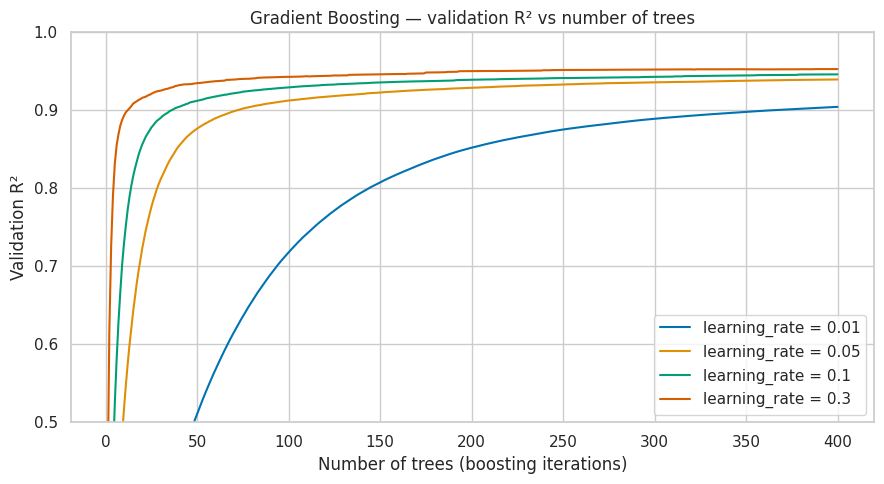

,learning_rate,best_val_R2,trees_at_best,val_R2_at_400
0,0.01,0.9044,400,0.9044
1,0.05,0.9395,400,0.9395
2,0.10,0.9461,400,0.9461
3,0.30,0.9529,395,0.9528


In [19]:
# ---- 3.3 Learning rate vs number of trees (validation curve) ----
# hold out 10% of the TRAINING set as a validation set (the test set stays untouched)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_p, y_train, test_size=0.1, random_state=RANDOM_STATE,
                                            stratify=pd.qcut(y_train, q=5, labels=False))
learning_rates = [0.01, 0.05, 0.1, 0.3]
N_TREES = 400

plt.figure(figsize=(9, 5))
lr_rows = []
for lr in learning_rates:
    m = HistGradientBoostingRegressor(learning_rate=lr, max_iter=N_TREES, early_stopping=False,
                                      random_state=RANDOM_STATE).fit(X_tr, y_tr)
    # staged_predict gives the prediction after 1, 2, ..., N trees -> one fit gives the whole curve
    val_r2 = [r2_score(y_val, p) for p in m.staged_predict(X_val)]
    plt.plot(range(1, N_TREES + 1), val_r2, label=f"learning_rate = {lr}")
    lr_rows.append({"learning_rate": lr, "best_val_R2": max(val_r2), "trees_at_best": int(np.argmax(val_r2)) + 1,
                    "val_R2_at_400": val_r2[-1]})
plt.ylim(0.5, 1.0)
plt.title("Gradient Boosting — validation R² vs number of trees")
plt.xlabel("Number of trees (boosting iterations)"); plt.ylabel("Validation R²")
plt.legend(); plt.tight_layout(); plt.show()
pd.DataFrame(lr_rows).round(4)

**📝 What this shows:** A small learning rate learns slowly and needs many more trees, while a big one reaches a good score quickly.

## C3 — Hyperparameter tuning (RandomizedSearchCV)
Searched on a **stratified 30,000-row subsample** of the training set with 3-fold CV (for speed). **Early stopping** is switched on,
so each candidate stops adding trees when its internal validation score stops improving (up to 1000 trees).
The best settings are then re-trained on the full training set.

In [20]:
# ---- 3.4 RandomizedSearchCV ----
sub_idx, _ = train_test_split(np.arange(len(X_train_p)), train_size=30000, random_state=RANDOM_STATE,
                              stratify=pd.qcut(y_train, q=5, labels=False))
X_sub, y_sub = X_train_p[sub_idx], y_train.values[sub_idx]

param_dist = {
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_leaf_nodes": [15, 31, 63, 127],     # size of each tree
    "min_samples_leaf": [5, 20, 50],
    "l2_regularization": [0.0, 0.1, 1.0],
}
search = RandomizedSearchCV(
    HistGradientBoostingRegressor(max_iter=1000, early_stopping=True, n_iter_no_change=20,
                                  validation_fraction=0.1, random_state=RANDOM_STATE),
    param_dist, n_iter=10, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring="r2", random_state=RANDOM_STATE, return_train_score=True, refit=False,
)
start = time.time()
search.fit(X_sub, y_sub)
print(f"Search time: {time.time() - start:.1f} s")

best_params = search.best_params_
print("Best parameters :", best_params)
print("Best CV R2 (subsample): %.4f" % search.best_score_)

cv_res = pd.DataFrame(search.cv_results_)
cv_res[["param_learning_rate", "param_max_leaf_nodes", "param_min_samples_leaf", "param_l2_regularization",
        "mean_train_score", "mean_test_score"]].sort_values("mean_test_score", ascending=False).round(4)

Search time: 424.4 s
Best parameters : {'min_samples_leaf': 5, 'max_leaf_nodes': 127, 'learning_rate': 0.05, 'l2_regularization': 1.0}
Best CV R2 (subsample): 0.9463


,param_learning_rate,param_max_leaf_nodes,param_min_samples_leaf,param_l2_regularization,mean_train_score,mean_test_score
0,0.05,127,5,1.0,0.9818,0.9463
8,0.05,63,5,0.1,0.9798,0.9460
9,0.05,63,5,0.0,0.9781,0.9454
6,0.20,15,5,1.0,0.9697,0.9438
5,0.05,15,5,0.0,0.9661,0.9426
1,0.05,63,20,0.0,0.9697,0.9400
2,0.10,127,20,0.1,0.9735,0.9385
7,0.05,31,50,0.1,0.9585,0.9334
3,0.03,15,20,1.0,0.9498,0.9330
4,0.03,63,50,0.1,0.9580,0.9321


**📝 What this shows:** A learning rate of 0.05 works best, as long as the model is allowed to build enough trees.

In [21]:
# ---- 3.5 Re-train the best settings on the FULL training set & report improvement ----
start = time.time()
gbr_best = HistGradientBoostingRegressor(**best_params, max_iter=1000, early_stopping=True, n_iter_no_change=20,
                                         validation_fraction=0.1, random_state=RANDOM_STATE)
gbr_best.fit(X_train_p, y_train)
print(f"Training time: {time.time() - start:.1f} s | trees used (early stopping): {gbr_best.n_iter_}")

y_pred = gbr_best.predict(X_test_p)
y_pred_train = gbr_best.predict(X_train_p)
tuned_scores = regression_metrics(y_test, y_pred)

compare = pd.DataFrame(
    [regression_metrics(y_test, y_pred_classic), default_scores, tuned_scores],
    index=["Classic GBM default", "Hist GBM default", "Hist GBM tuned"],
)
compare.loc["Improvement (tuned − hist default)"] = compare.iloc[2] - compare.iloc[1]
compare.loc["Improvement (tuned − classic default)"] = compare.iloc[2] - compare.iloc[0]
print("Train R2 (tuned): %.4f  | Test R2 (tuned): %.4f" % (r2_score(y_train, y_pred_train), tuned_scores["R2"]))
compare.round(4)

Training time: 60.0 s | trees used (early stopping): 616


Train R2 (tuned): 0.9804  | Test R2 (tuned): 0.9619


,R2,RMSE,MAE
Classic GBM default,0.8905,3285.5704,2153.3191
Hist GBM default,0.9363,2505.7678,1480.5337
Hist GBM tuned,0.9619,1938.0616,1114.0200
Improvement (tuned − hist default),0.0256,-567.7062,-366.5137
Improvement (tuned − classic default),0.0714,-1347.5088,-1039.2991


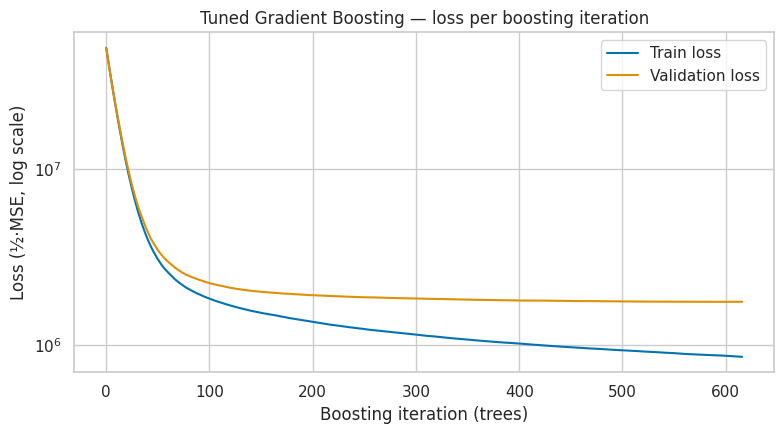

In [22]:
# ---- 3.6 Training curve of the tuned model ----
# (validation_score_ is recorded on the internal 10% validation split used for early stopping)
plt.figure(figsize=(8, 4.5))
plt.plot(-gbr_best.train_score_, label="Train loss")
plt.plot(-gbr_best.validation_score_, label="Validation loss")
plt.yscale("log")
plt.title("Tuned Gradient Boosting — loss per boosting iteration")
plt.xlabel("Boosting iteration (trees)"); plt.ylabel("Loss (½·MSE, log scale)")
plt.legend(); plt.tight_layout(); plt.show()

**📝 What this shows:** Training stopped by itself at 616 trees, because the validation score was no longer improving.

In [23]:
# ---- 3.7 5-fold cross-validated R2 of the tuned model (full training set) ----
cv_scores = cross_val_score(gbr_best, X_train_p, y_train, cv=kf, scoring="r2")
print("CV R2 per fold:", np.round(cv_scores, 4))
print(f"Mean CV R2: {cv_scores.mean():.4f}  (± {cv_scores.std():.4f})")

CV R2 per fold: [0.9542 0.9653 0.962  0.9546 0.9619]
Mean CV R2: 0.9596  (± 0.0044)


## C4 — Feature importance

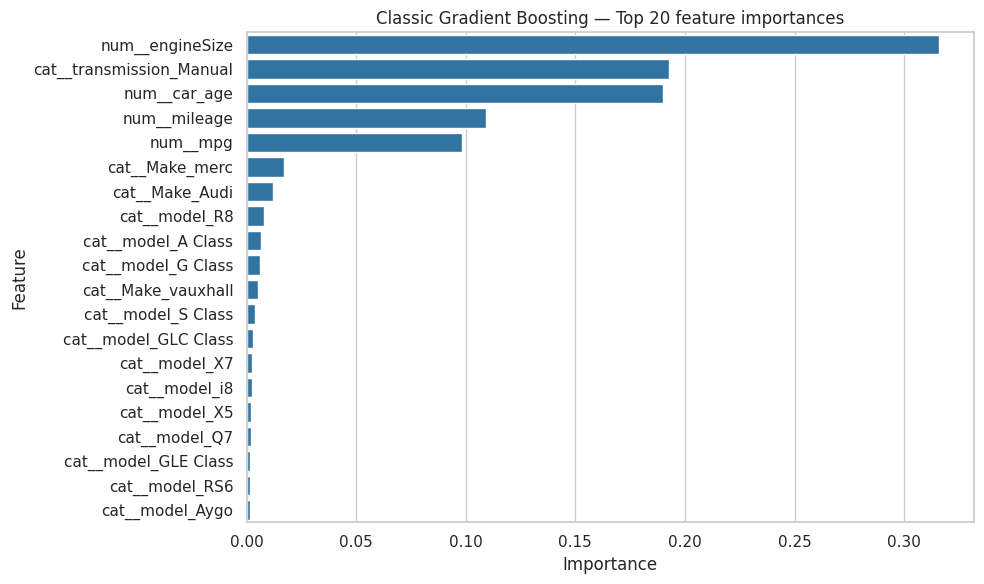

In [24]:
# ---- 3.8 Impurity-based importance (classic GBM) ----
def original_column(name):
    name = name.split("__", 1)[1]                       # remove 'num__' / 'cat__'
    for c in cat_cols:
        if name.startswith(c + "_"):
            return c
    return name

imp = pd.DataFrame({"feature": feature_names, "importance": gbr_classic.feature_importances_})
imp["original"] = imp["feature"].apply(original_column)
top = imp.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top, y="feature", x="importance", color="tab:blue")
plt.title("Classic Gradient Boosting — Top 20 feature importances")
plt.xlabel("Importance"); plt.ylabel("Feature")
plt.tight_layout(); plt.show()

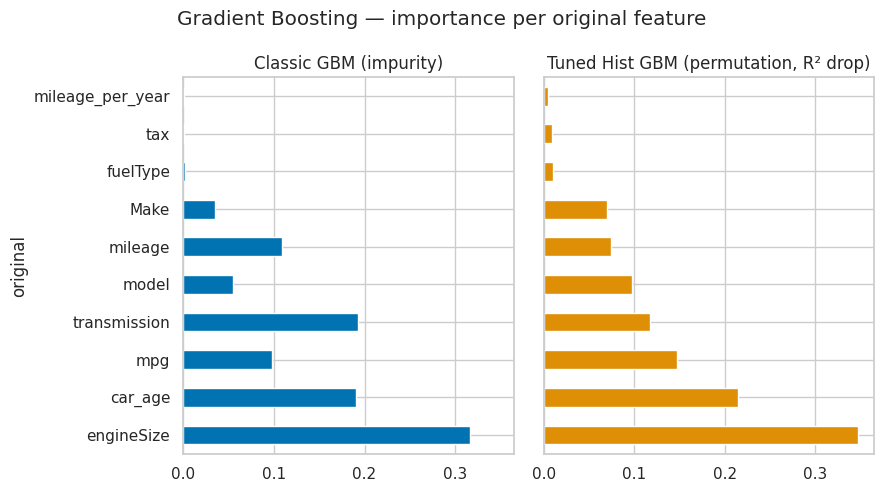

,Classic GBM (impurity),"Tuned Hist GBM (permutation, R² drop)"
original,,
engineSize,0.3161,0.3473
car_age,0.1900,0.2143
mpg,0.0983,0.1476
transmission,0.1927,0.1174
model,0.0548,0.0974
mileage,0.1092,0.0748
Make,0.0352,0.0695
fuelType,0.0020,0.0106
tax,0.0011,0.0092


In [25]:
# ---- 3.9 Permutation importance (tuned hist GBM) ----
# HistGradientBoosting has no feature_importances_, so we measure how much test R2 DROPS
# when one column is randomly shuffled (on 5,000 test rows to keep it quick).
rng = np.random.RandomState(RANDOM_STATE)
perm_idx = rng.choice(len(X_test_p), 5000, replace=False)
perm = permutation_importance(gbr_best, X_test_p[perm_idx], y_test.values[perm_idx],
                              scoring="r2", n_repeats=3, random_state=RANDOM_STATE)

perm_df = pd.DataFrame({"feature": feature_names, "importance": perm.importances_mean})
perm_df["original"] = perm_df["feature"].apply(original_column)
grouped = pd.DataFrame({
    "Classic GBM (impurity)": imp.groupby("original")["importance"].sum(),
    "Tuned Hist GBM (permutation, R² drop)": perm_df.groupby("original")["importance"].sum(),
}).sort_values("Tuned Hist GBM (permutation, R² drop)", ascending=False)

grouped.plot(kind="barh", figsize=(9, 5), subplots=True, layout=(1, 2), sharey=True, legend=False)
plt.suptitle("Gradient Boosting — importance per original feature")
plt.tight_layout(); plt.show()
grouped.round(4)

**📝 What this shows:** Both methods agree that engine size and car age matter most, but they disagree about transmission.

## C4 — Visualisation

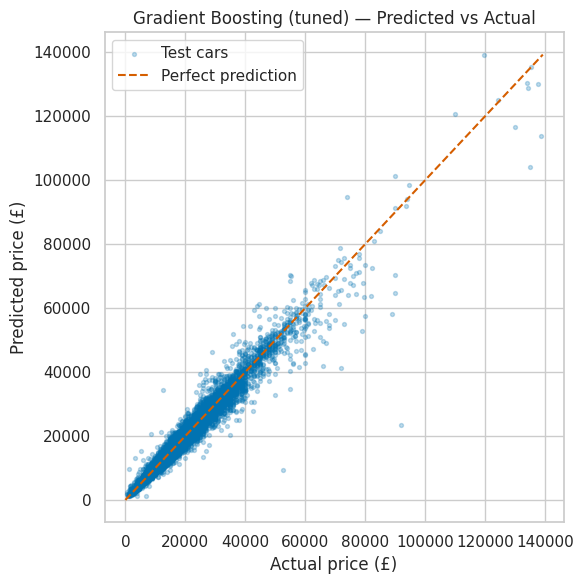

In [26]:
# ---- 3.10 Predicted vs Actual ----
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.25, s=8, label="Test cars")
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.title("Gradient Boosting (tuned) — Predicted vs Actual")
plt.xlabel("Actual price (£)"); plt.ylabel("Predicted price (£)")
plt.legend(); plt.tight_layout(); plt.show()

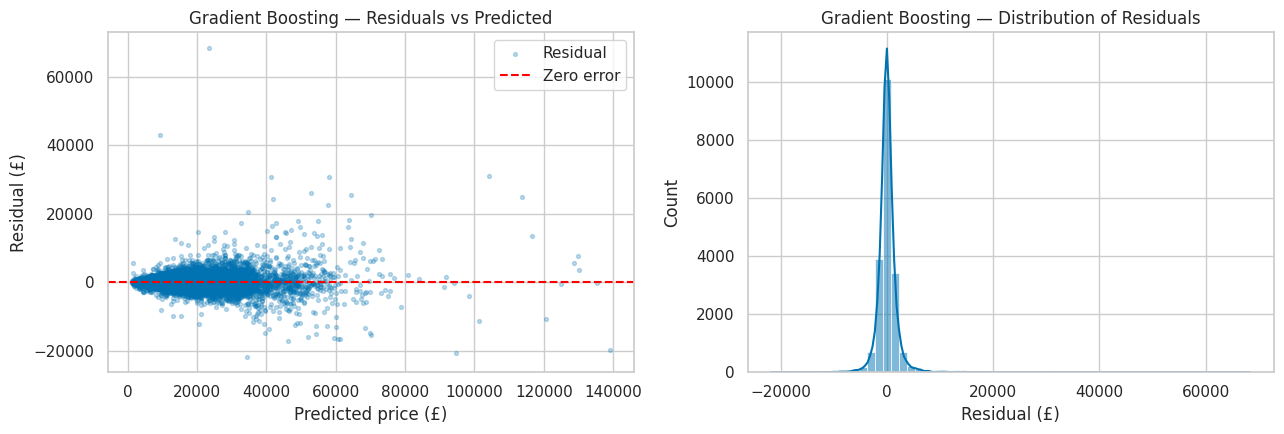

In [27]:
# ---- 3.11 Residual plots ----
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_pred, residuals, alpha=0.25, s=8, label="Residual")
axes[0].axhline(0, color="red", linestyle="--", label="Zero error")
axes[0].set_title("Gradient Boosting — Residuals vs Predicted")
axes[0].set_xlabel("Predicted price (£)"); axes[0].set_ylabel("Residual (£)"); axes[0].legend()

sns.histplot(residuals, bins=60, kde=True, ax=axes[1])
axes[1].set_title("Gradient Boosting — Distribution of Residuals")
axes[1].set_xlabel("Residual (£)"); axes[1].set_ylabel("Count")
plt.tight_layout(); plt.show()

**📝 What this shows:** The errors are the smallest of all 10 models, slightly better than Random Forest.

In [28]:
# ---- 3.12 Save results for the final 10-model comparison table ----
os.makedirs("../results", exist_ok=True)
RESULTS_FILE = "../results/regression_results.csv"
MODEL_NAME = "Gradient Boosting Regressor"

row = pd.DataFrame([{
    "Model": MODEL_NAME,
    **tuned_scores,
    "CV_R2_mean": cv_scores.mean(),
    "Tuned": "Yes (RandomizedSearchCV)",
    "Best_params": str({**best_params, "n_trees": int(gbr_best.n_iter_)}),
}])
if os.path.exists(RESULTS_FILE):
    old = pd.read_csv(RESULTS_FILE)
    row = pd.concat([old[old["Model"] != MODEL_NAME], row], ignore_index=True)
row.to_csv(RESULTS_FILE, index=False)
row.round(4)

,Model,R2,RMSE,MAE,CV_R2_mean,Tuned,Best_params
0,Linear Regression,0.8581,3740.5466,2236.4595,0.8641,No (baseline),-
1,Ridge Regression,0.8581,3740.4517,2236.5020,0.8641,Yes (GridSearchCV),"{'alpha': 0.03162, 'solver': 'auto'}"
2,Lasso Regression,0.8580,3740.9234,2236.8250,0.8641,Yes (GridSearchCV),{'alpha': 0.01}
3,ElasticNet Regression,0.8580,3741.4670,2236.9651,0.8641,Yes (GridSearchCV),"{'alpha': 0.001, 'l1_ratio': 1.0}"
4,Polynomial Regression,0.9114,2955.0887,1728.8830,0.9151,Yes (GridSearchCV),"{'degree': 3, 'interaction_only': False}"
5,Decision Tree Regressor,0.9416,2398.3671,1360.5098,0.9311,Yes (GridSearchCV),"{'max_depth': 25, 'min_samples_leaf': 3}"
6,Random Forest Regressor,0.9594,2001.0139,1163.3206,0.9554,Yes (RandomizedSearchCV),"{'n_estimators': 150, 'min_samples_leaf': 1, '..."
7,Gradient Boosting Regressor,0.9619,1938.0616,1114.0200,0.9596,Yes (RandomizedSearchCV),"{'min_samples_leaf': 5, 'max_leaf_nodes': 127,..."


## Summary

**📝 In short:** Gradient Boosting is the best model at 0.962, because each new tree fixes the mistakes of the trees before it.